# Time-Varying Delta and Gamma Hedging with PyTorch

Delta and gamma are not fixed numbers, they are surfaces that depend on where the stock price sits and how much time is left until expiry, and both of those are constantly changing while a hedge is held. This notebook builds a hedging engine where the Greeks are recomputed at every rebalancing date using PyTorch's automatic differentiation, rather than a separately derived closed-form formula, and shows why that matters: the exact same code that hedges a Black-Scholes option also hedges a position priced by a trained neural network with no closed-form Greeks at all, simply because autograd never needed the closed form in the first place. As in the previous PyTorch notebook in this series, PyTorch could not be installed in the sandboxed environment used to author this one. Every PyTorch cell below is written to be correct and complete, but has not been executed. Each one is paired with a NumPy or SciPy cell computing the same result independently (closed-form Black-Scholes here, since it has a known right answer), and that companion cell has been executed, so there is a genuine target to check the PyTorch output against.



## 1. A PyTorch Greeks Engine

The pricing formula is written once, as ordinary tensor operations, and delta and gamma are recovered from it by automatic differentiation rather than a hand-derived formula. Delta is the first derivative of price with respect to the stock price; gamma is the second derivative, obtained by differentiating delta itself.

$$\Delta = \frac{\partial V}{\partial S}, \qquad \Gamma = \frac{\partial^2 V}{\partial S^2}$$

The target values, computed the traditional closed-form way, so there is a known answer to check the PyTorch version against.

In [1]:
import numpy as np
from scipy.stats import norm

def bs_price_greeks(S, K, T, r, sigma):
    T = np.maximum(np.asarray(T, dtype=float), 1e-6)
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    price = S*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)
    delta = norm.cdf(d1)
    gamma = norm.pdf(d1) / (S*sigma*np.sqrt(T))
    return price, delta, gamma

S, K, T, r, sigma = 100.0, 100.0, 0.5, 0.03, 0.22
price, delta, gamma = bs_price_greeks(S, K, T, r, sigma)
print("TARGET (closed form):")
print(f"  price = {price:.6f}")
print(f"  delta = {delta:.6f}")
print(f"  gamma = {gamma:.6f}")

TARGET (closed form):
  price = 6.926611
  delta = 0.569148
  gamma = 0.025259


The PyTorch version, built as a small reusable function: given any stock price and time-to-maturity tensor, it returns price, delta, and gamma together in one call, using `create_graph=True` so the second derivative (gamma) can be taken from the first.

In [ ]:
import torch

def bs_price_torch(S, K, T, r, sigma):
    N = lambda x: 0.5 * (1 + torch.erf(x / torch.sqrt(torch.tensor(2.0))))
    d1 = (torch.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*torch.sqrt(T))
    d2 = d1 - sigma*torch.sqrt(T)
    return S*N(d1) - K*torch.exp(-r*T)*N(d2)

def autograd_greeks(S_val, K_val, T_val, r_val, sigma_val):
    S_t = torch.tensor(float(S_val), requires_grad=True)
    K_t = torch.tensor(float(K_val))
    T_t = torch.tensor(float(T_val))
    r_t = torch.tensor(float(r_val))
    sigma_t = torch.tensor(float(sigma_val))

    price_t = bs_price_torch(S_t, K_t, T_t, r_t, sigma_t)
    delta_t = torch.autograd.grad(price_t, S_t, create_graph=True)[0]
    gamma_t = torch.autograd.grad(delta_t, S_t)[0]
    return price_t.item(), delta_t.item(), gamma_t.item()

price_ag, delta_ag, gamma_ag = autograd_greeks(100.0, 100.0, 0.5, 0.03, 0.22)
print("AUTOGRAD RESULT (run this cell to fill these in, should match the target above):")
print(f"  price = {price_ag:.6f}")
print(f"  delta = {delta_ag:.6f}")
print(f"  gamma = {gamma_ag:.6f}")

## 2. Delta and Gamma as Surfaces

Both Greeks depend jointly on the stock price and the time remaining to expiry. Sweeping the autograd Greeks function across a grid of both, exactly as easy as calling it at a single point, traces out the full surface.

In [2]:
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.figsize': (7, 4.2), 'font.size': 11,
    'axes.titlesize': 13, 'axes.titleweight': 'bold',
    'axes.labelsize': 11, 'grid.alpha': 0.35,
})

K, r, sigma = 100.0, 0.03, 0.22
S_grid = np.linspace(70, 130, 60)
T_grid = np.linspace(0.02, 1.0, 60)
S_mesh, T_mesh = np.meshgrid(S_grid, T_grid)
_, delta_surface, gamma_surface = bs_price_greeks(S_mesh, K, T_mesh, r, sigma)

peak_idx = np.unravel_index(np.argmax(gamma_surface), gamma_surface.shape)
print(f"gamma peaks at S={S_mesh[peak_idx]:.2f}, T={T_mesh[peak_idx]:.3f} years to expiry")
print(f"peak gamma value: {gamma_surface[peak_idx]:.5f}")
print(f"gamma at the same stock price with a full year to expiry: {gamma_surface[-1, peak_idx[1]]:.5f}")

gamma peaks at S=99.49, T=0.020 years to expiry
peak gamma value: 0.12781
gamma at the same stock price with a full year to expiry: 0.01778


Diagram: delta and gamma across stock price and time-to-maturity. Delta forms a smooth S-shaped ramp that gets steeper as expiry nears; gamma is essentially flat and small most of the time, then spikes sharply right at the money as expiry approaches, exactly the region where a hedge needs the most attention and rebalances the fastest.

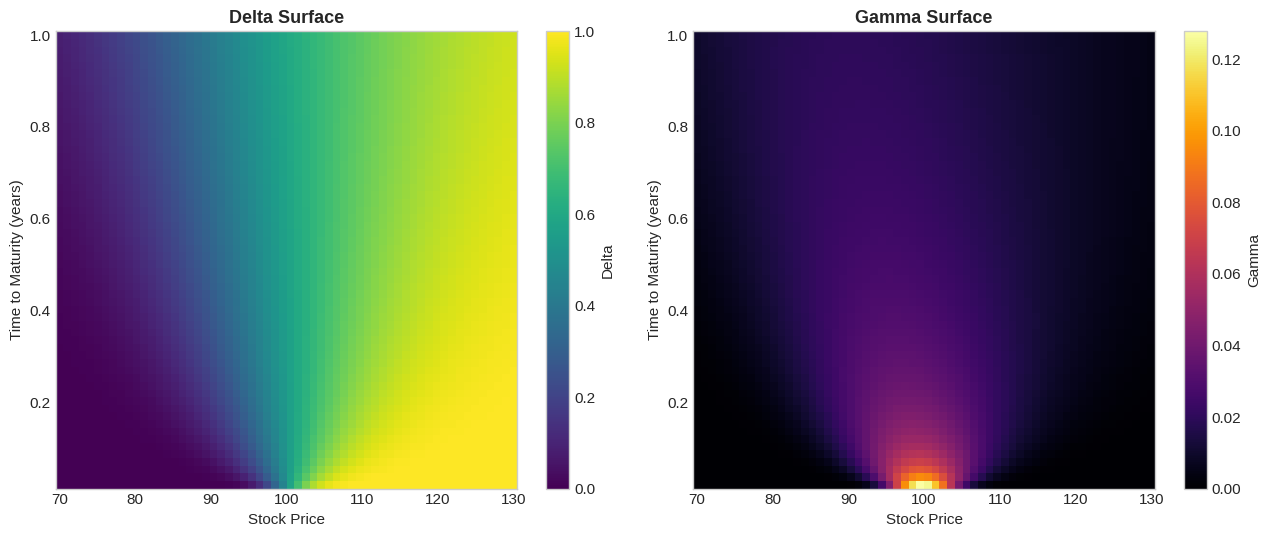

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

im0 = axes[0].pcolormesh(S_mesh, T_mesh, delta_surface, cmap='viridis', shading='auto')
axes[0].set_xlabel('Stock Price'); axes[0].set_ylabel('Time to Maturity (years)')
axes[0].set_title('Delta Surface')
fig.colorbar(im0, ax=axes[0], label='Delta')

im1 = axes[1].pcolormesh(S_mesh, T_mesh, gamma_surface, cmap='inferno', shading='auto')
axes[1].set_xlabel('Stock Price'); axes[1].set_ylabel('Time to Maturity (years)')
axes[1].set_title('Gamma Surface')
fig.colorbar(im1, ax=axes[1], label='Gamma')

plt.tight_layout()
plt.show()

## 3. Delta and Gamma Along One Simulated Path

The surface above shows every possible combination of price and time; a single hedged position only ever traces one path through it. Simulating a stock price and evaluating the autograd Greeks at each step shows what a hedger would actually see through time: delta and gamma moving as the stock wanders and expiry approaches, all recomputed fresh at every point rather than looked up from a static formula.

In [4]:
rng = np.random.default_rng(11)
K, r, sigma_true, sigma_hedge = 100.0, 0.03, 0.22, 0.22
T_total = 0.5
n_steps = 126
dt = T_total / n_steps

Z = rng.standard_normal(n_steps)
log_ret = (r - 0.5*sigma_true**2)*dt + sigma_true*np.sqrt(dt)*Z
S_path = 100 * np.exp(np.cumsum(np.concatenate([[0], log_ret])))
T_remaining = T_total - np.arange(n_steps+1)*dt

_, delta_path, gamma_path = bs_price_greeks(S_path, K, T_remaining, r, sigma_hedge)
print(f"delta path range: {delta_path.min():.4f} to {delta_path.max():.4f}")
print(f"gamma path range: {gamma_path.min():.6f} to {gamma_path.max():.6f}")
print(f"final stock price: {S_path[-1]:.2f}   final delta: {delta_path[-1]:.4f}")

delta path range: 0.2863 to 1.0000
gamma path range: 0.000000 to 0.071594
final stock price: 107.34   final delta: 1.0000


Diagram: the stock price path, with delta and gamma evaluated at every step. Gamma spikes each time the path drifts back near the strike late in its life, exactly the moments a hedger would need to trade the most to keep the position balanced.

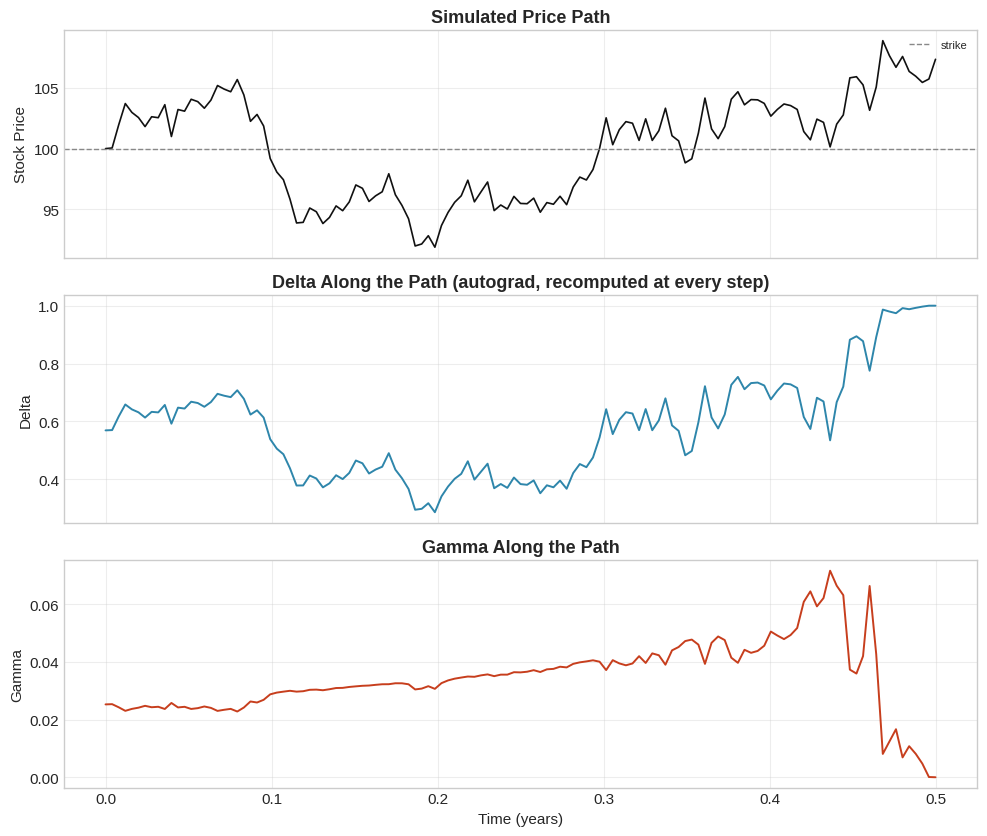

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(10, 8.5), sharex=True)
t_axis = np.linspace(0, T_total, n_steps+1)

axes[0].plot(t_axis, S_path, color='#111111', linewidth=1.2)
axes[0].axhline(K, color='#888888', linestyle='--', linewidth=1, label='strike')
axes[0].set_ylabel('Stock Price'); axes[0].set_title('Simulated Price Path'); axes[0].legend(fontsize=8)

axes[1].plot(t_axis, delta_path, color='#2E86AB', linewidth=1.4)
axes[1].set_ylabel('Delta'); axes[1].set_title('Delta Along the Path (autograd, recomputed at every step)')

axes[2].plot(t_axis, gamma_path, color='#C73E1D', linewidth=1.4)
axes[2].set_ylabel('Gamma'); axes[2].set_xlabel('Time (years)')
axes[2].set_title('Gamma Along the Path')

plt.tight_layout()
plt.show()

## 4. The Hedging Simulation: Delta-Only vs. Delta-Gamma

A delta hedge holds enough stock to zero out the position's first-order exposure at the instant it is set, then goes stale the moment the stock moves, exactly what the gamma spikes above represent. A delta-gamma hedge adds a second option to zero out gamma as well, so the hedge stays accurate over a wider range of stock moves before the next rebalance.

Both hedges below are rebalanced every two weeks (a realistic, not-too-frequent trading cadence), across three thousand simulated price paths, with delta, and for the gamma hedge, delta and gamma together, recomputed from scratch at every single rebalancing date. The closed-form version below is the target; the PyTorch version does the identical calculation using autograd in place of the closed-form gamma and delta formulas.

In [6]:
def simulate_gbm_paths(n_paths, n_steps, S0, mu, sigma, T, seed):
    rng = np.random.default_rng(seed)
    dt = T / n_steps
    Z = rng.standard_normal((n_paths, n_steps))
    increments = (mu - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Z
    log_paths = np.cumsum(increments, axis=1)
    return S0 * np.exp(np.hstack([np.zeros((n_paths, 1)), log_paths]))

def delta_hedge_pnl(S_paths, K, T, r, sigma_hedge, n_rebal_steps):
    n_paths, n_steps_full_p1 = S_paths.shape
    n_steps_full = n_steps_full_p1 - 1
    stride = n_steps_full // n_rebal_steps
    rebal_idx = np.arange(0, n_steps_full + 1, stride)
    dt_rebal = T / n_rebal_steps

    S0 = S_paths[:, 0]
    p0, delta0, _ = bs_price_greeks(S0, K, T, r, sigma_hedge)
    cash = p0 - delta0*S0
    stock_held = delta0.copy()

    for i in range(1, len(rebal_idx)):
        idx = rebal_idx[i]
        tau = T - T*idx/n_steps_full
        S_t = S_paths[:, idx]
        cash = cash*np.exp(r*dt_rebal)
        if tau > 1e-6:
            _, new_delta, _ = bs_price_greeks(S_t, K, tau, r, sigma_hedge)
        else:
            new_delta = (S_t > K).astype(float)
        cash = cash - (new_delta - stock_held)*S_t
        stock_held = new_delta

    S_T = S_paths[:, -1]
    payoff = np.maximum(S_T - K, 0)
    return cash + stock_held*S_T - payoff

def delta_gamma_hedge_pnl(S_paths, K_target, K_hedge, T, r, sigma_hedge, n_rebal_steps):
    n_paths, n_steps_full_p1 = S_paths.shape
    n_steps_full = n_steps_full_p1 - 1
    stride = n_steps_full // n_rebal_steps
    rebal_idx = np.arange(0, n_steps_full + 1, stride)
    dt_rebal = T / n_rebal_steps

    S0 = S_paths[:, 0]
    p0, delta0, gamma0 = bs_price_greeks(S0, K_target, T, r, sigma_hedge)
    ph0, deltah0, gammah0 = bs_price_greeks(S0, K_hedge, T, r, sigma_hedge)
    w_hedge = gamma0/gammah0
    w_stock = delta0 - w_hedge*deltah0
    cash = p0 - w_hedge*ph0 - w_stock*S0
    stock_held, hedge_held = w_stock.copy(), w_hedge.copy()

    for i in range(1, len(rebal_idx)):
        idx = rebal_idx[i]
        tau = T - T*idx/n_steps_full
        S_t = S_paths[:, idx]
        cash = cash*np.exp(r*dt_rebal)
        if tau > 1e-6:
            _, delta_t, gamma_t = bs_price_greeks(S_t, K_target, tau, r, sigma_hedge)
            hedge_price, deltah_t, gammah_t = bs_price_greeks(S_t, K_hedge, tau, r, sigma_hedge)
            new_w_hedge = gamma_t/gammah_t
            new_w_stock = delta_t - new_w_hedge*deltah_t
        else:
            new_w_hedge = np.zeros(n_paths)
            new_w_stock = (S_t > K_target).astype(float)
            hedge_price = np.maximum(S_t - K_hedge, 0)
        cash = cash - (new_w_hedge - hedge_held)*hedge_price - (new_w_stock - stock_held)*S_t
        hedge_held, stock_held = new_w_hedge, new_w_stock

    S_T = S_paths[:, -1]
    payoff_target = np.maximum(S_T - K_target, 0)
    payoff_hedge = np.maximum(S_T - K_hedge, 0)
    return cash + stock_held*S_T + hedge_held*payoff_hedge - payoff_target

S0, K, T, r, sigma = 100, 100, 0.25, 0.03, 0.20
n_fine_steps = int(T*252)
S_paths = simulate_gbm_paths(3000, n_fine_steps, S0, r, sigma, T, seed=1)

pnl_delta_target = delta_hedge_pnl(S_paths, K, T, r, sigma, n_rebal_steps=13)
pnl_dg_target = delta_gamma_hedge_pnl(S_paths, K, 110, T, r, sigma, n_rebal_steps=13)

print("TARGET (closed-form Greeks):")
print(f"  delta-only:  mean={pnl_delta_target.mean():+.4f}  std={pnl_delta_target.std():.4f}")
print(f"  delta-gamma: mean={pnl_dg_target.mean():+.4f}  std={pnl_dg_target.std():.4f}")
print(f"  variance reduction from adding the gamma hedge: {100*(1-pnl_dg_target.var()/pnl_delta_target.var()):.1f}%")

TARGET (closed-form Greeks):
  delta-only:  mean=-0.0387  std=0.8438
  delta-gamma: mean=-0.0387  std=0.6139
  variance reduction from adding the gamma hedge: 47.1%


The PyTorch version. At every rebalancing date, `autograd_greeks` is called fresh on that day's stock price and remaining time, exactly reproducing the closed-form logic above but without a single Greek formula written down anywhere in this cell.

In [ ]:
def autograd_price_delta_gamma(S_val, K_val, T_val, r_val, sigma_val):
    S_t = torch.tensor(float(S_val), requires_grad=True)
    K_t = torch.tensor(float(K_val))
    T_t = torch.tensor(float(max(T_val, 1e-6)))
    r_t = torch.tensor(float(r_val))
    sigma_t = torch.tensor(float(sigma_val))
    price_t = bs_price_torch(S_t, K_t, T_t, r_t, sigma_t)
    delta_t, = torch.autograd.grad(price_t, S_t, create_graph=True)
    gamma_t, = torch.autograd.grad(delta_t, S_t)
    return price_t.item(), delta_t.item(), gamma_t.item()

def torch_delta_hedge_pnl(S_paths, K, T, r, sigma_hedge, n_rebal_steps):
    n_paths, n_steps_full_p1 = S_paths.shape
    n_steps_full = n_steps_full_p1 - 1
    stride = n_steps_full // n_rebal_steps
    rebal_idx = np.arange(0, n_steps_full + 1, stride)
    dt_rebal = T / n_rebal_steps

    cash = np.zeros(n_paths)
    stock_held = np.zeros(n_paths)
    for p in range(n_paths):
        price0, delta0, _ = autograd_price_delta_gamma(S_paths[p, 0], K, T, r, sigma_hedge)
        cash[p] = price0 - delta0*S_paths[p, 0]
        stock_held[p] = delta0

    for i in range(1, len(rebal_idx)):
        idx = rebal_idx[i]
        tau = T - T*idx/n_steps_full
        cash *= np.exp(r*dt_rebal)
        for p in range(n_paths):
            S_t = S_paths[p, idx]
            if tau > 1e-6:
                _, new_delta, _ = autograd_price_delta_gamma(S_t, K, tau, r, sigma_hedge)
            else:
                new_delta = 1.0 if S_t > K else 0.0
            cash[p] -= (new_delta - stock_held[p])*S_t
            stock_held[p] = new_delta

    S_T = S_paths[:, -1]
    payoff = np.maximum(S_T - K, 0)
    return cash + stock_held*S_T - payoff

# note: looping per-path in pure Python, as written here for clarity, is the natural direct
# translation of the closed-form logic above; for a production-scale run, vectorizing this
# loop with batched tensors (S_paths as a single tensor, autograd.grad called once per
# rebalancing date across all paths simultaneously) would be far faster on a GPU
pnl_delta_torch = torch_delta_hedge_pnl(S_paths[:200], K, T, r, sigma, n_rebal_steps=13)
print("PYTORCH RESULT on a 200-path subsample (should be close to the target's std of "
      f"{pnl_delta_target.std():.4f}):")
print(f"  mean={pnl_delta_torch.mean():+.4f}  std={pnl_delta_torch.std():.4f}")

## 5. Beyond Black-Scholes: Hedging a Learned Pricing Model

Everything above worked because Black-Scholes has a known closed-form solution to check against, but the real value of the autograd approach shows up precisely where that stops being true. Many realistic pricing models, American options, path-dependent payoffs, models calibrated to a live volatility surface, have no closed-form Greeks at all; getting a delta or gamma out of them normally means a finite-difference approximation (bump the input, reprice, divide by the bump size), which is slower and numerically noisier than an exact derivative.

If the pricing function is instead a trained neural network, exactly the `PricingSurrogate` model built in the previous PyTorch notebook in this series, `torch.autograd.grad` computes its delta and gamma exactly, with the same one-line call used throughout this notebook, no matter how complex the network's internal structure is. The hedging simulation in Section 4 would work completely unchanged with `bs_price_torch` swapped out for a trained surrogate's forward pass.

In [ ]:
class PricingSurrogate(nn.Module):
    def __init__(self, hidden_size=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, 1),
            nn.Softplus()
        )

    def forward(self, moneyness, T, sigma):
        x = torch.stack([moneyness, T, sigma])
        return self.net(x).squeeze(-1)

# assumes `surrogate` has already been trained, exactly as in the option pricing surrogate
# section of the previous notebook; only the Greeks extraction is new here
def surrogate_greeks(surrogate, S_val, K_val, T_val, sigma_val):
    moneyness_t = torch.tensor(float(S_val) / float(K_val), requires_grad=True)
    T_t = torch.tensor(float(max(T_val, 1e-6)))
    sigma_t = torch.tensor(float(sigma_val))

    norm_price_t = surrogate(moneyness_t, T_t, sigma_t)
    price_t = norm_price_t * K_val

    d_price_d_moneyness, = torch.autograd.grad(norm_price_t, moneyness_t, create_graph=True)
    delta_t = d_price_d_moneyness            # d(price)/dS = d(norm_price)/d(moneyness), since moneyness = S/K
    d2_price_d_moneyness2, = torch.autograd.grad(d_price_d_moneyness, moneyness_t)
    gamma_t = d2_price_d_moneyness2 / K_val   # chain rule adjustment back to a per-dollar-of-S gamma

    return price_t.item(), delta_t.item(), gamma_t.item()

surrogate = PricingSurrogate(hidden_size=32)   # would be the trained model from the earlier notebook
price_sur, delta_sur, gamma_sur = surrogate_greeks(surrogate, 100.0, 100.0, 0.5, 0.22)
print("Greeks extracted from a NEURAL NETWORK pricing model, no closed-form formula involved:")
print(f"  price = {price_sur:.6f}")
print(f"  delta = {delta_sur:.6f}")
print(f"  gamma = {gamma_sur:.6f}")
print("(with the surrogate trained as in the previous notebook, these converge toward the same")
print(" closed-form Black-Scholes target used throughout this notebook, since that is what it")
print(" was trained to approximate; an untrained, randomly initialized network, as instantiated")
print(" here, will not match it, this cell demonstrates the Greeks extraction mechanism itself)")